In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load the dataset

In [2]:
df = pd.read_csv('Heart_Disease_Prediction.csv')

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


understand data

In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [5]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


EDA

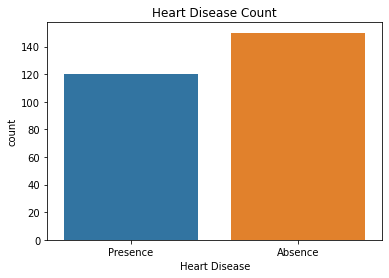

In [8]:
sns.countplot(x='Heart Disease', data=df)
plt.title('Heart Disease Count')
plt.show()

This bargraph shows the total number of people who have heart disease and those who do not. From the graph, we can clearly see how the data is distributed between the two classes. As one bar is much taller than the other, it indicates class imbalance in the dataset. This information is important because an imbalanced dataset can affect model performance. Understanding the target distribution helps us choose proper evaluation metrics like precision and recall instead of only accuracy.

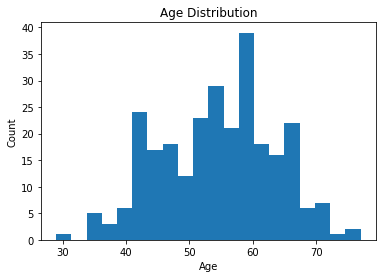

In [9]:
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

This histogram shows the distribution of age among the patients in the dataset. The x-axis represents age values, and the y-axis represents the number of people in each age group. From the graph, we can observe which age range has the highest number of patients. This helps us understand whether heart disease cases are more common in younger, middle-aged, or older people. It also helps identify skewness and whether most patients fall in a particular age range.

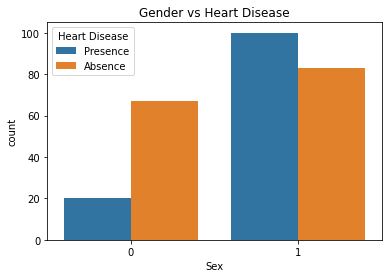

In [10]:
sns.countplot(x='Sex', hue='Heart Disease', data=df)
plt.title('Gender vs Heart Disease')
plt.show()

This graph compares heart disease occurrence between males and females. Different colors represent whether heart disease is present or not. From the graph, we can observe which gender has a higher number of heart disease cases. This analysis helps us understand if gender plays an important role in heart disease prediction. It also helps in identifying gender-based health risk patterns in the dataset.

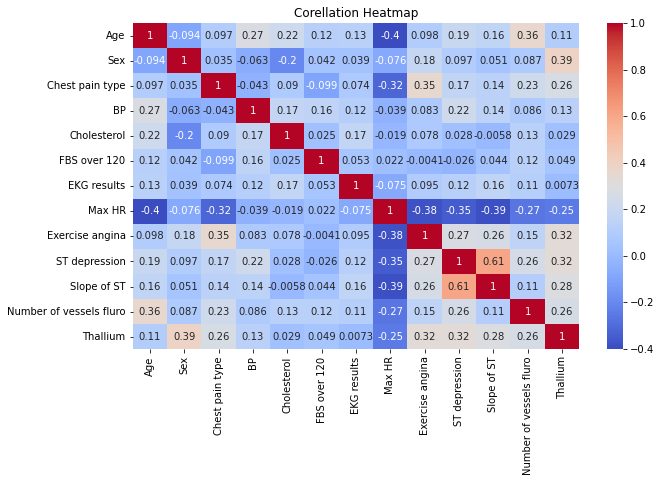

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Corellation Heatmap')
plt.show()

This heatmap shows the correlation between all numerical variables in the dataset. Each cell represents the strength and direction of the relationship between two features. Darker colors indicate stronger correlation, while lighter colors indicate weaker correlation. From this graph, we can identify which features are strongly related to heart disease and which features are highly correlated with each other. This helps in feature selection and in avoiding multicollinearity problems in machine learning models.

Data Preprocessing

In [13]:
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col].fillna(df[col].mean(), inplace=True)

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease_Presence'],
      dtype='object')

Split data into feature and target

In [23]:
X = df.drop('Heart Disease_Presence', axis=1)
y = df['Heart Disease_Presence']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature scaling

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Make Predictions

In [30]:
y_pred = model.predict(X_test)

Model Evaluation

In [31]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9074074074074074


[[31  2]
 [ 3 18]]


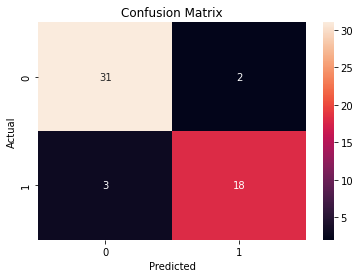

In [32]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

This confusion matrix shows the performance of the classification model. It displays the number of correct and incorrect predictions made by the model. True positives represent correctly predicted heart disease cases, while true negatives represent correctly predicted non-heart disease cases. False positives and false negatives show incorrect predictions. This graph helps us understand where the model is making mistakes and whether it is better at predicting heart disease or non-heart disease cases.

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

